# Simple Tag (PettingZoo + MARLlib)

This notebook experiments with the **Simple Tag** multi-agent environment and includes
both value-based baselines and a MARLlib MAPPO training section.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

from pettingzoo.mpe import simple_tag_v3


/tmp/ipykernel_2338580/3484269951.py:6: DeprecationWarning: The environment `pettingzoo.mpe` has been moved to `mpe2` and will be removed in a future release.Please update your imports.
  from pettingzoo.mpe import simple_tag_v3


In [2]:
# Environment config
NUM_GOOD = 1
NUM_ADVERSARIES = 3
NUM_OBSTACLES = 2
MAX_CYCLES = 100

env = simple_tag_v3.env(
    num_good=NUM_GOOD,
    num_adversaries=NUM_ADVERSARIES,
    num_obstacles=NUM_OBSTACLES,
    max_cycles=MAX_CYCLES,
    continuous_actions=False,
    render_mode="rgb_array",
    dynamic_rescaling=True,
)

print("Agents:", env.possible_agents)
for agent in env.possible_agents:
    print(f"{agent}: action_space={env.action_space(agent)}, obs_space={env.observation_space(agent)}")


Agents: ['adversary_0', 'adversary_1', 'adversary_2', 'agent_0']
adversary_0: action_space=Discrete(5), obs_space=Box(-inf, inf, (16,), float32)
adversary_1: action_space=Discrete(5), obs_space=Box(-inf, inf, (16,), float32)
adversary_2: action_space=Discrete(5), obs_space=Box(-inf, inf, (16,), float32)
agent_0: action_space=Discrete(5), obs_space=Box(-inf, inf, (14,), float32)


In [3]:
def collect_rollout_frames(env, max_iter=600, seed=0):
    env.reset(seed=seed)
    frames = []

    for agent in env.agent_iter(max_iter=max_iter):
        obs, reward, terminated, truncated, info = env.last()

        if terminated or truncated:
            action = None
        else:
            action = env.action_space(agent).sample()

        env.step(action)
        frame = env.render()
        if frame is not None:
            frames.append(frame)

    env.close()
    return frames

frames = collect_rollout_frames(env, max_iter=600, seed=42)
print(f"Collected {len(frames)} frames")


Collected 404 frames


In [4]:
def animate_frames(frames, interval=60):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.axis("off")

    img = ax.imshow(frames[0])

    def _update(i):
        img.set_data(frames[i])
        return (img,)

    anim = animation.FuncAnimation(
        fig,
        _update,
        frames=len(frames),
        interval=interval,
        blit=True,
    )
    plt.close(fig)
    return HTML(anim.to_jshtml())


def plot_reward_history(reward_history, title, save_path=None, figsize=(10, 5)):
    plt.figure(figsize=figsize)
    for agent_name, rewards in reward_history.items():
        plt.plot(rewards, label=agent_name, alpha=0.85)

    plt.xlabel("Episode")
    plt.ylabel("Episode Reward")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def evaluate_parallel_agents(
    agents,
    env_fn,
    env_kwargs,
    seed=0,
    expected_num_agents=None,
    greedy=True,
    stop_on_done=False,
):
    """Run one parallel-env evaluation rollout and return (frames, episode_rewards)."""
    eval_env = env_fn(**env_kwargs)

    reset_out = eval_env.reset(seed=seed)
    if isinstance(reset_out, tuple):
        obs_dict, _ = reset_out
    else:
        obs_dict = reset_out

    frames = []
    episode_rewards = {a: 0.0 for a in agents.keys()}

    saved_eps = {}
    if greedy:
        for name, agent in agents.items():
            if hasattr(agent, "epsilon_explore"):
                saved_eps[name] = agent.epsilon_explore
                agent.epsilon_explore = 0.0

    try:
        while eval_env.agents:
            active_agents = list(eval_env.agents)

            if expected_num_agents is not None and len(active_agents) != expected_num_agents:
                break

            actions = {
                a: agents[a].act(obs_dict[a])
                for a in active_agents
                if a in agents and a in obs_dict
            }
            if not actions:
                break

            next_obs, rewards, terminations, truncations, infos = eval_env.step(actions)

            frame = eval_env.render()
            if frame is not None:
                frames.append(frame)

            for a in actions:
                episode_rewards[a] += float(rewards.get(a, 0.0))

            obs_dict = next_obs

            if stop_on_done and (any(terminations.values()) or any(truncations.values())):
                break
    finally:
        for name, val in saved_eps.items():
            agents[name].epsilon_explore = val
        eval_env.close()

    return frames, episode_rewards


def plot_eval_rewards(episode_rewards, title, figsize=(8, 4)):
    plt.figure(figsize=figsize)
    plt.bar(list(episode_rewards.keys()), list(episode_rewards.values()))
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("Evaluation Episode Reward")
    plt.title(title)
    plt.tight_layout()
    plt.show()


animate_frames(frames[:250], interval=50)


## Train Individual Dueling DDQN Agents

Train one `DuelingDDqnAgent` per environment agent, then plot per-agent episode rewards.


In [6]:
import sys
from pathlib import Path
from collections import defaultdict
from tqdm.auto import trange

# Make local DQN module imports robust regardless of notebook launch directory.
candidate_dirs = [Path.cwd(), Path.cwd() / "discrete_action_space" / "DQN"]
for d in candidate_dirs:
    if (d / "DuelingDDQN.py").exists():
        if str(d) not in sys.path:
            sys.path.insert(0, str(d))
        break

from DuelingDDQN import DuelingDDqnAgent


/vol/bitbucket/jhl323/fypenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
EPISODES = 1000
BATCH_SIZE = 64
TARGET_UPDATE_EVERY = 10
SEED = 123

train_env = simple_tag_v3.parallel_env(
    num_good=NUM_GOOD,
    num_adversaries=NUM_ADVERSARIES,
    num_obstacles=NUM_OBSTACLES,
    max_cycles=MAX_CYCLES,
    continuous_actions=False,
    render_mode=None,
)

# Initialize once to inspect spaces and build agents.
reset_out = train_env.reset(seed=SEED)
if isinstance(reset_out, tuple):
    obs_dict, _ = reset_out
else:
    obs_dict = reset_out

agent_names = list(train_env.possible_agents)
num_agents = len(agent_names)
obs_dims = {a: int(np.asarray(train_env.observation_space(a).shape).prod()) for a in agent_names}
num_actions = {a: train_env.action_space(a).n for a in agent_names}
print("Number of agents:", num_agents)

agents = {}
for idx, agent_name in enumerate(agent_names):
    agents[agent_name] = DuelingDDqnAgent(
        agent_id=idx,
        obs_dim=obs_dims[agent_name],
        num_agents=num_agents,
        num_actions=num_actions[agent_name],
        epsilon_explore=1.0,
        gamma=0.95,
        lr=1e-3,
        decay_rate=0.995,
        buffer_size=10000,
        use_gpu=True,
    )

reward_history = {a: [] for a in agent_names}

for ep in trange(EPISODES, desc="Training DDQN"):
    reset_out = train_env.reset(seed=SEED + ep)
    if isinstance(reset_out, tuple):
        obs_dict, _ = reset_out
    else:
        obs_dict = reset_out

    episode_rewards = defaultdict(float)

    while train_env.agents:
        active_agents = list(train_env.agents)

        actions = {a: agents[a].act(obs_dict[a]) for a in active_agents}

        next_obs, rewards, terminations, truncations, infos = train_env.step(actions)

        for a in active_agents:
            done = terminations.get(a, False) or truncations.get(a, False)
            next_state = next_obs.get(a, np.zeros(obs_dims[a], dtype=np.float32))
            r = rewards.get(a, 0.0)

            agents[a].update(
                state=obs_dict[a],
                actions=actions[a],
                rewards=r,
                next_state=next_state,
                done=done,
                batch_size=BATCH_SIZE,
            )
            episode_rewards[a] += r

        obs_dict = next_obs

    for a in agent_names:
        reward_history[a].append(float(episode_rewards[a]))

    for ag in agents.values():
        ag.decay_parameters()

    if (ep + 1) % TARGET_UPDATE_EVERY == 0:
        for ag in agents.values():
            ag.update_target_network()

train_env.close()
print("Training complete.")


Number of agents: 4


Training DDQN: 100%|██████████| 1000/1000 [27:11<00:00,  1.63s/it]

Training complete.


In [14]:
plot_reward_history(
    reward_history,
    title="Dueling DDQN Training Reward Curve (Simple Tag)",
    save_path="Individual_DuelingDDQN_1000eps.png",
)


NameError: name 'reward_history' is not defined

<Figure size 1000x500 with 0 Axes>

Collected 100 evaluation frames.
Episode rewards: {'adversary_0': 0.0, 'adversary_1': 0.0, 'adversary_2': 0.0, 'agent_0': -11.75}


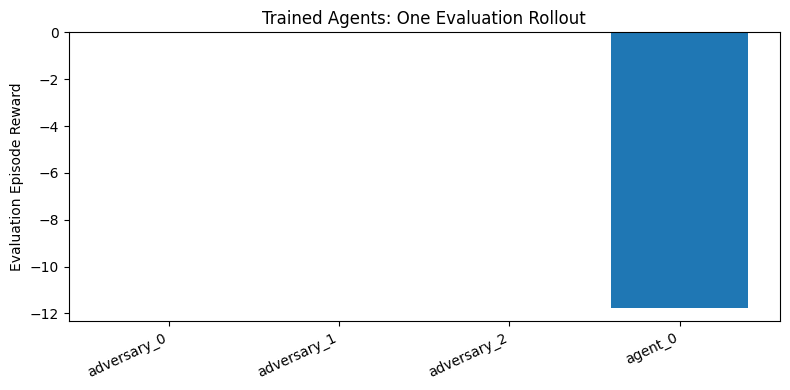

In [ ]:
# Visualize trained agents playing one evaluation episode
EVAL_SEED = 2026

eval_env_kwargs = dict(
    num_good=NUM_GOOD,
    num_adversaries=NUM_ADVERSARIES,
    num_obstacles=NUM_OBSTACLES,
    max_cycles=MAX_CYCLES,
    continuous_actions=False,
    render_mode="rgb_array",
    dynamic_rescaling=True,
)

frames, episode_rewards = evaluate_parallel_agents(
    agents=agents,
    env_fn=simple_tag_v3.parallel_env,
    env_kwargs=eval_env_kwargs,
    seed=EVAL_SEED,
    greedy=True,
)

print(f"Collected {len(frames)} evaluation frames.")
print("Episode rewards:", {k: round(v, 2) for k, v in episode_rewards.items()})

if frames:
    display(animate_frames(frames, interval=60))

plot_eval_rewards(
    episode_rewards,
    title="Trained Agents: One Evaluation Rollout",
)


## Train Dueling SRE-DDQN Agents 

This section trains a Strategically Robust Equilibrium (SRE) variant. 1v1 takes 51 min to train


In [6]:
import sys
from pathlib import Path
from collections import defaultdict
from tqdm.auto import trange

# Make local DQN module imports robust regardless of notebook launch directory.
candidate_dirs = [Path.cwd(), Path.cwd() / "discrete_action_space" / "DQN"]
for d in candidate_dirs:
    if (d / "DuelingSREDDQN.py").exists():
        if str(d) not in sys.path:
            sys.path.insert(0, str(d))
        break

from SreDuelingDDQN import SreDuelingDDqnAgent


In [7]:
from pathlib import Path

SRE_EPISODES = 1000
SRE_BATCH_SIZE = 64
SRE_TARGET_UPDATE_EVERY = 10
SRE_CHECKPOINT_INTERVAL = 200
SRE_CHECKPOINT_DIR = Path("checkpoints_sre_dueling_ddqn")
SRE_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
SRE_SEED = 321

SRE_NUM_GOOD = 1
SRE_NUM_ADVERSARIES = 1
SRE_NUM_OBSTACLES = NUM_OBSTACLES

sre_train_env = simple_tag_v3.parallel_env(
    num_good=SRE_NUM_GOOD,
    num_adversaries=SRE_NUM_ADVERSARIES,
    num_obstacles=SRE_NUM_OBSTACLES,
    max_cycles=MAX_CYCLES,
    continuous_actions=False,
    render_mode=None,
)

reset_out = sre_train_env.reset(seed=SRE_SEED)
if isinstance(reset_out, tuple):
    sre_obs_dict, _ = reset_out
else:
    sre_obs_dict = reset_out

sre_agent_names = list(sre_train_env.possible_agents)
sre_num_agents = len(sre_agent_names)
if sre_num_agents != 2:
    raise ValueError(f"Expected 2 agents for SRE training, got {sre_num_agents}.")

sre_obs_dims = {
    a: int(np.asarray(sre_train_env.observation_space(a).shape).prod())
    for a in sre_agent_names
}
sre_num_actions = {a: sre_train_env.action_space(a).n for a in sre_agent_names}

sre_agents = {}
for idx, agent_name in enumerate(sre_agent_names):
    sre_agents[agent_name] = SreDuelingDDqnAgent(
        agent_id=idx,
        obs_dim=sre_obs_dims[agent_name],
        num_agents=sre_num_agents,
        num_actions=sre_num_actions[agent_name],
        pathwrap_path="pathwrap.so",
        epsilon_robust=1.0,
        epsilon_explore=1.0,
        gamma=0.95,
        lr=1e-3,
        decay_rate=0.995,
        buffer_size=10000,
        use_gpu=True,
        sre_num_repeats=3,
    )

sre_reward_history = {a: [] for a in sre_agent_names}

for ep in trange(SRE_EPISODES, desc="Training Dueling SRE-DDQN"):
    reset_out = sre_train_env.reset(seed=SRE_SEED + ep)
    if isinstance(reset_out, tuple):
        sre_obs_dict, _ = reset_out
    else:
        sre_obs_dict = reset_out

    episode_rewards = defaultdict(float)

    while sre_train_env.agents:
        active_agents = list(sre_train_env.agents)
        if len(active_agents) != sre_num_agents:
            break

        actions = {a: sre_agents[a].act(sre_obs_dict[a]) for a in sre_agent_names}

        next_obs, rewards, terminations, truncations, infos = sre_train_env.step(actions)

        joint_actions = np.asarray([actions[a] for a in sre_agent_names], dtype=np.int64)
        joint_rewards = np.asarray([rewards.get(a, 0.0) for a in sre_agent_names], dtype=np.float32)

        for a in sre_agent_names:
            done = terminations.get(a, False) or truncations.get(a, False)
            next_state = next_obs.get(a, np.zeros(sre_obs_dims[a], dtype=np.float32))

            sre_agents[a].update(
                state=sre_obs_dict[a],
                actions=joint_actions,
                rewards=joint_rewards,
                next_state=next_state,
                done=done,
                batch_size=SRE_BATCH_SIZE,
            )
            episode_rewards[a] += float(rewards.get(a, 0.0))

        sre_obs_dict = next_obs

        if any(terminations.values()) or any(truncations.values()):
            break

    for a in sre_agent_names:
        sre_reward_history[a].append(float(episode_rewards[a]))

    for ag in sre_agents.values():
        ag.decay_parameters()

    if (ep + 1) % SRE_TARGET_UPDATE_EVERY == 0:
        for ag in sre_agents.values():
            ag.update_target_network()

    if (ep + 1) % SRE_CHECKPOINT_INTERVAL == 0:
        for a in sre_agent_names:
            sre_agents[a].save_checkpoint(
                SRE_CHECKPOINT_DIR / f"dueling_sre_{a}_ep{ep + 1}.pt"
            )

for a in sre_agent_names:
    sre_agents[a].save_checkpoint(SRE_CHECKPOINT_DIR / f"dueling_sre_{a}_final.pt")

sre_train_env.close()
print(f"SRE training complete. Checkpoints saved to: {SRE_CHECKPOINT_DIR.resolve()}")


Training Dueling SRE-DDQN: 100%|██████████| 1000/1000 [51:07<00:00,  3.07s/it]

SRE training complete. Checkpoints saved to: /homes/jhl323/SRE-DQN/discrete_action_space/DQN/checkpoints_sre_dueling_ddqn


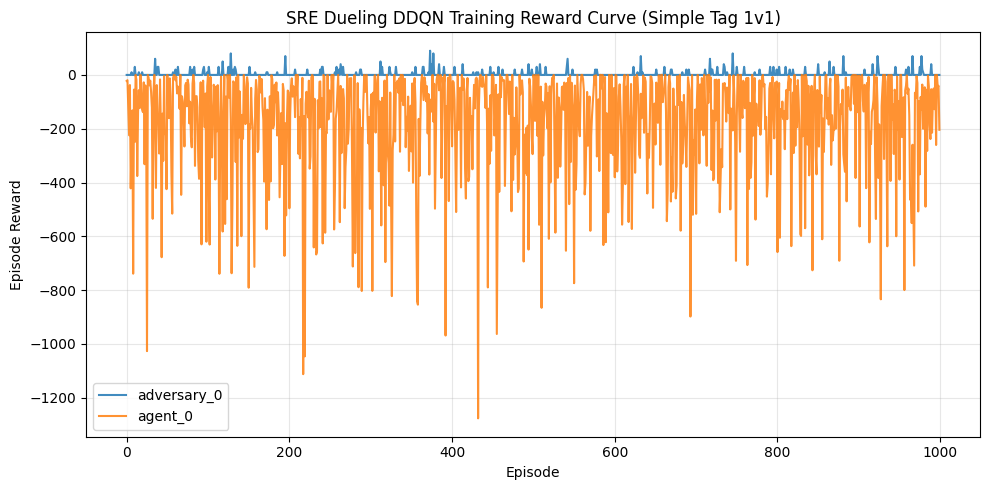

In [13]:
plot_reward_history(
    sre_reward_history,
    title="SRE Dueling DDQN Training Reward Curve (Simple Tag 1v1)",
    save_path="SRE_DuelingDDQN_1000eps.png",
)


Collected 100 SRE evaluation frames.
Episode rewards: {'adversary_0': 0.0, 'agent_0': -123.89}


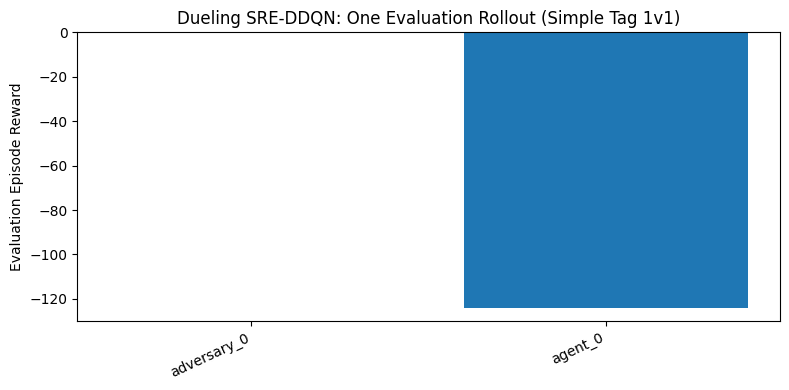

In [9]:
# Visualize trained SRE agents playing one evaluation episode
SRE_EVAL_SEED = 2027

sre_eval_env_kwargs = dict(
    num_good=SRE_NUM_GOOD,
    num_adversaries=SRE_NUM_ADVERSARIES,
    num_obstacles=SRE_NUM_OBSTACLES,
    max_cycles=MAX_CYCLES,
    continuous_actions=False,
    render_mode="rgb_array",
    dynamic_rescaling=True,
)

sre_frames, sre_episode_rewards = evaluate_parallel_agents(
    agents=sre_agents,
    env_fn=simple_tag_v3.parallel_env,
    env_kwargs=sre_eval_env_kwargs,
    seed=SRE_EVAL_SEED,
    expected_num_agents=sre_num_agents,
    greedy=True,
    stop_on_done=True,
)

print(f"Collected {len(sre_frames)} SRE evaluation frames.")
print("Episode rewards:", {k: round(v, 2) for k, v in sre_episode_rewards.items()})

if sre_frames:
    display(animate_frames(sre_frames, interval=60))

plot_eval_rewards(
    sre_episode_rewards,
    title="SRE Dueling DDQN: One Evaluation Rollout (Simple Tag 1v1)",
)


## Train MAPPO with MARLlib (Simple Tag)

This section uses MARLlib's MPE integration to train MAPPO on `simple_tag`,
then plots training reward metrics from the Ray Tune progress output.


In [12]:
from marllib import marl

# MAPPO training config
MAPPO_STOP = {"timesteps_total": 300_000}
MAPPO_NUM_WORKERS = 1
MAPPO_NUM_GPUS = 0
MAPPO_LOCAL_MODE = True
MAPPO_SHARE_POLICY = "group"
MAPPO_CHECKPOINT_FREQ = 20

# Build MARLlib MPE simple_tag env and MAPPO trainer/model
mappo_env = marl.make_env(environment_name="mpe", map_name="simple_tag")
mappo = marl.algos.mappo(hyperparam_source="mpe")
mappo_model = marl.build_model(
    mappo_env,
    mappo,
    {"core_arch": "mlp", "encode_layer": "128-128"},
)

print("Starting MARLlib MAPPO training on MPE simple_tag...")
mappo_fit_result = mappo.fit(
    mappo_env,
    mappo_model,
    stop=MAPPO_STOP,
    local_mode=MAPPO_LOCAL_MODE,
    num_workers=MAPPO_NUM_WORKERS,
    num_gpus=MAPPO_NUM_GPUS,
    share_policy=MAPPO_SHARE_POLICY,
    checkpoint_freq=MAPPO_CHECKPOINT_FREQ,
)
print("MAPPO training complete.")


ModuleNotFoundError: No module named 'ray.rllib.utils.torch_ops'

In [ ]:
import pandas as pd

def _extract_progress_df(fit_result):
    """Best-effort extraction of a training dataframe from Ray Tune/MARLlib fit output."""
    # Ray Tune ExperimentAnalysis style
    if hasattr(fit_result, "trial_dataframes") and fit_result.trial_dataframes:
        trial_path, df = max(
            fit_result.trial_dataframes.items(),
            key=lambda kv: len(kv[1]),
        )
        return df.copy(), str(trial_path)

    # Some wrappers may return tuple/list containing analysis
    if isinstance(fit_result, (tuple, list)):
        for item in fit_result:
            if hasattr(item, "trial_dataframes") and item.trial_dataframes:
                trial_path, df = max(
                    item.trial_dataframes.items(),
                    key=lambda kv: len(kv[1]),
                )
                return df.copy(), str(trial_path)

    return None, None

mappo_progress_df, mappo_trial_src = _extract_progress_df(mappo_fit_result)

# Fallback: latest progress.csv under ~/ray_results
if mappo_progress_df is None:
    ray_root = Path.home() / "ray_results"
    progress_files = sorted(
        ray_root.glob("**/progress.csv"),
        key=lambda x: x.stat().st_mtime,
        reverse=True,
    )
    if not progress_files:
        raise RuntimeError(
            "Could not find MAPPO progress data. No trial dataframe and no progress.csv found."
        )
    latest_progress = progress_files[0]
    mappo_progress_df = pd.read_csv(latest_progress)
    mappo_trial_src = str(latest_progress)

print(f"Loaded MAPPO metrics from: {mappo_trial_src}")
print(f"Rows: {len(mappo_progress_df)}, Columns: {len(mappo_progress_df.columns)}")
mappo_progress_df.tail(3)


In [ ]:
# Plot core reward metrics if present
x_col = "timesteps_total" if "timesteps_total" in mappo_progress_df.columns else "training_iteration"
if x_col not in mappo_progress_df.columns:
    raise RuntimeError("Could not find a suitable x-axis column (timesteps_total/training_iteration).")

reward_candidates = [
    "episode_reward_mean",
    "episode_return_mean",
    "env_runners/episode_return_mean",
]
reward_cols = [c for c in reward_candidates if c in mappo_progress_df.columns]

# Fallback to policy-level reward means if global metric names differ.
if not reward_cols:
    reward_cols = [c for c in mappo_progress_df.columns if "policy_reward_mean" in c]

if not reward_cols:
    raise RuntimeError(
        "No reward metric columns found in MAPPO progress dataframe. "
        "Inspect mappo_progress_df.columns for your MARLlib/Ray version."
    )

plt.figure(figsize=(10, 5))
for col in reward_cols[:6]:
    y = pd.to_numeric(mappo_progress_df[col], errors="coerce")
    y_smooth = y.rolling(window=10, min_periods=1).mean()
    plt.plot(mappo_progress_df[x_col], y_smooth, label=f"{col} (smoothed)", alpha=0.9)

plt.xlabel(x_col)
plt.ylabel("Reward")
plt.title("MARLlib MAPPO Training Curve (MPE simple_tag)")
plt.grid(alpha=0.3)
plt.legend(loc="best")
plt.tight_layout()
plt.show()
